In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import statistics
import math
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
from sklearn.cluster import KMeans
import dofitPython_functions as LogFit 


In [2]:
#xrdsNorESM = xr.open_dataset("/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilev-1_4Peter.nc")
#SMRXRdsNorESM = xrdsNorESM.sel(station='SMR-II')


In [3]:
#xrdsNorESMall_levs = xr.open_dataset("/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc")
#SMRNorlevs =  xrdsNorESMall_levs.sel(station='SMR-II')
#PeterNor =  xr.open_dataset('/share/pech2273/SMRPeterVariables2.nc')
PeterNor =  xr.open_dataset('/share/pech2273/SMRPeterVariablesWithMode14.nc')
PeterNor = PeterNor.chunk({'time':100})


In [4]:
rows = []
for i in range(1, 15):
    radius = f'NMR{i:02d}'
    sigma = f'SIGMA{i:02d}'
    nconc = f'NCONC{i:02d}'
    if radius not in PeterNor:
        continue

    da = PeterNor[radius].isel(lev=-1).chunk({'time': -1})  # Make time a single chunk
    q25 = da.quantile(0.25).values.item()  # Extract scalar from array
    q75 = da.quantile(0.75).values.item()
    da = PeterNor[sigma].isel(lev=-1).chunk({'time': -1})  # Make time a single chunk
    q25s = da.quantile(0.25).values.item()  # Extract scalar from array
    q75s = da.quantile(0.75).values.item()
    da = PeterNor[nconc].isel(lev=-1).chunk({'time': -1})  # Make time a single chunk
    q25n = da.quantile(0.25).values.item()  # Extract scalar from array
    q75n = da.quantile(0.75).values.item()
    # Append row as a dict
    rows.append({
        
        "Median Radius 25th Percentile (nm)": q25,
        "Median Radius 75th Percentile (nm)": q75,
        "Std dev 25th Percentile": q25s,
        "Std dev 75th Percentile": q75s,
        "Number Concentration 25th Percentile (# cm-3)": q25n,
        "Number Concentration 75th Percentile (# cm-3)": q75n,
    })

# Create DataFrame
df = pd.DataFrame(rows)

In [5]:
df

,Median Radius 25th Percentile (nm),Median Radius 75th Percentile (nm),Std dev 25th Percentile,Std dev 75th Percentile,Number Concentration 25th Percentile (# cm-3),Number Concentration 75th Percentile (# cm-3)
0,20.375055,31.334023,1.441052,1.573968,201.054703,1474.109863
1,25.166342,27.230494,1.754038,1.775390,42.296722,129.831635
2,43.032570,53.537891,1.769562,1.909682,83.120934,334.742249
3,85.018219,108.955467,1.520492,1.584533,1.656064,9.121675
4,223.310089,232.276825,1.573710,1.587230,0.074342,1.425072
5,631.037170,632.317505,1.997353,1.998493,0.000013,0.003609
6,58.460636,90.027832,1.692064,1.991831,1.497279,7.992325
7,301.453430,306.748901,1.715297,1.721197,0.123213,0.687379
8,748.224365,750.921326,1.602581,1.603930,0.034478,0.221284
9,24.000000,24.000000,1.800000,1.800000,23.488890,97.192261


In [6]:
# OutputNor['PDF01'].assign(SMRNorlevs['PDF01'])
time = PeterNor.indexes['time']
lev = PeterNor.indexes['lev']
OutputNor = xr.Dataset( coords = dict(lev = lev, time = time))
Output= xr.Dataset( coords = dict( time = time))

In [7]:
def createNorESMDistributions(Data, Xspace):
    ds=xr.Dataset()
    for i in range(1,14):
        if f'SIGMA{i:02d}' not in Data:
            continue   
        Data[f'dNdlogD{i:02d}'] = dNdlogD(Data[f'NCONC{i:02d}'],Xspace, Data[f'NMR{i:02d}'], Data[f'SIGMA{i:02d}'])        
    return 

def dNdlogD(N,x,mu,sigma):
    return N*np.exp(-(np.log10(x) - np.log10(mu*2))**2 / (2 * np.log10(sigma)**2))/ (np.log10(sigma) * np.sqrt(2 * np.pi))    

In [8]:
x = xr.DataArray(np.logspace(-0.5,4, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,4, num=200)})
createNorESMDistributions(PeterNor, x)

In [9]:


PeterNor['TotaldNdlogD']=PeterNor['dNdlogD01']
for i in range(2,14):
    if f'dNdlogD{i:02d}' not in PeterNor:
       continue
    PeterNor['TotaldNdlogD'] = PeterNor['TotaldNdlogD']+PeterNor[f'dNdlogD{i:02d}']

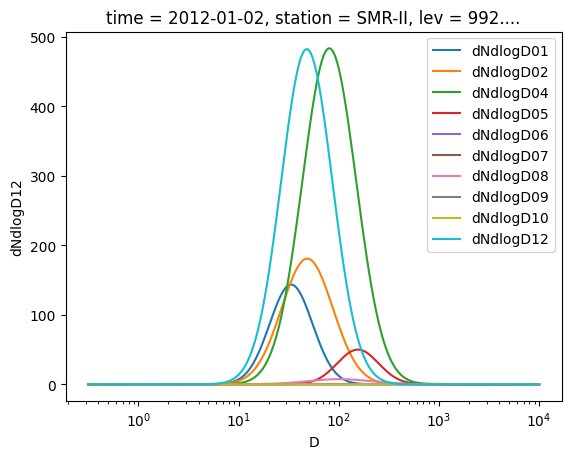

In [10]:

for i in range(1,15):
    if f'dNdlogD{i:02d}' not in PeterNor:
       continue
    PeterNor[f'dNdlogD{i:02d}'].isel(lev=-1, time = 0).plot(xscale='log', label = f'dNdlogD{i:02d}')
plt.legend()

Text(0.5, 1.0, 'NorESM Mean Aerosol Distribution for the First Layer')

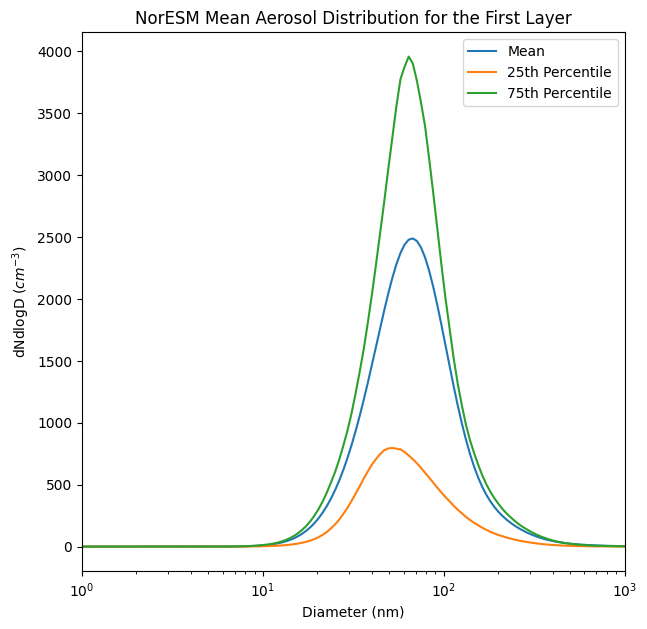

In [11]:
plt.figure(figsize = (7,7))

PeterNor['TotaldNdlogD'] = PeterNor['TotaldNdlogD'].compute()
PeterNor['TotaldNdlogD'].isel(lev = -1).mean('time').plot(xscale = 'log',xlim = [1,1000], label = 'Mean')
PeterNor['TotaldNdlogD'].isel(lev = -1).quantile(0.25, dim='time').plot(label = '25th Percentile')
PeterNor['TotaldNdlogD'].isel(lev = -1).quantile(0.75, dim='time').plot(label = '75th Percentile')
plt.legend()
plt.xlabel('Diameter (nm)')
plt.ylabel('dNdlogD ($cm^{-3}$)')
plt.title('NorESM Mean Aerosol Distribution for the First Layer')


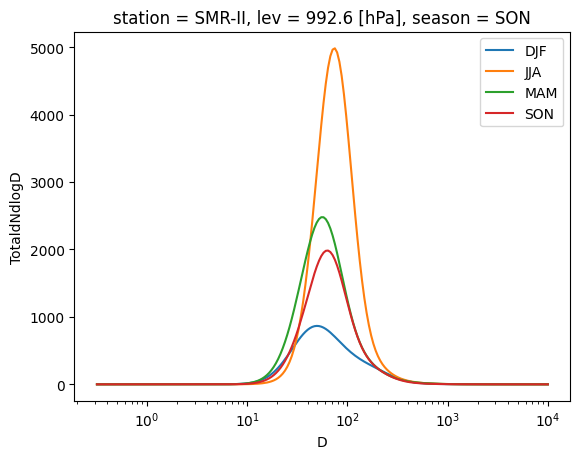

In [12]:
DS_ = PeterNor['TotaldNdlogD'].isel(lev = -1).groupby(PeterNor['time.season']).mean()
for seas in DS_.season:
    DS_.sel(season = seas).plot(xscale = 'log', label=seas.values)

plt.legend()

In [13]:
dx = xr.DataArray(np.logspace(-1.5,6, num=100), dims =['Dx'], coords= {'Dx':np.logspace(-1.5,6, num=100)})
for i in range (1,len(dx)):
    dx[i]= np.log10(x[i]/x[i-1])
dx[0]=dx[1]
deltax= dx[1]


In [17]:
def n70NorESM(Data, DeltaX = deltax):
    Data['Totaln70'] = Data['TotaldNdlogD'].where(Data['D']>70).sum('D')*DeltaX
    Data['Totaln50'] = Data['TotaldNdlogD'].where(Data['D']>82).sum('D')*DeltaX
    Data['Totaln150'] = Data['TotaldNdlogD'].where(Data['D']>150).sum('D')*DeltaX
    
    return 

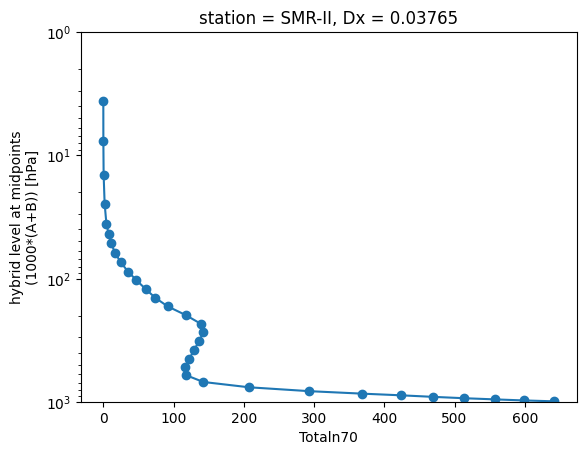

In [18]:
n70NorESM(PeterNor)
PeterNor['Totaln70'].mean('time').plot(y = 'lev', ylim = [1000,1], yscale = 'log', marker = 'o')

#plt.xlabel('CCN')


In [16]:
PeterNor['Totaln70'].isel(lev = -1).plot(yscale = 'log')

KeyError: "No variable named 'Totaln70'. Variables on the dataset include ['time', 'station', 'lev', 'SIGMA01', 'NMR01', ..., 'dNdlogD08', 'dNdlogD09', 'dNdlogD10', 'dNdlogD12', 'TotaldNdlogD']"

In [21]:
def DropletNumber(Data):
    Data['Droplets'] = Data['AWNC'].isel()/Data['FREQL']
    return 

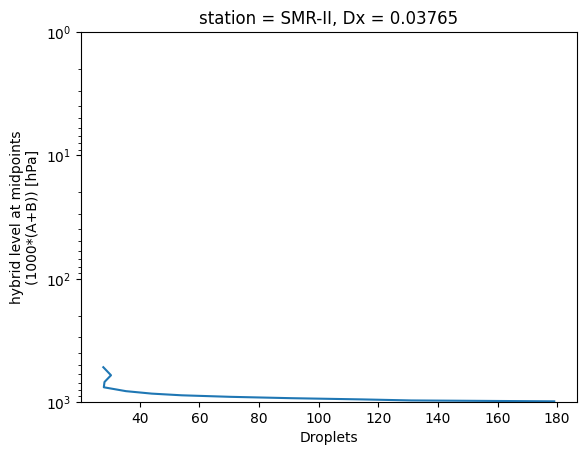

In [22]:
DropletNumber(PeterNor)
PeterNor['Droplets'].mean('time').plot(y = 'lev', ylim= [1000,1], yscale = 'log')


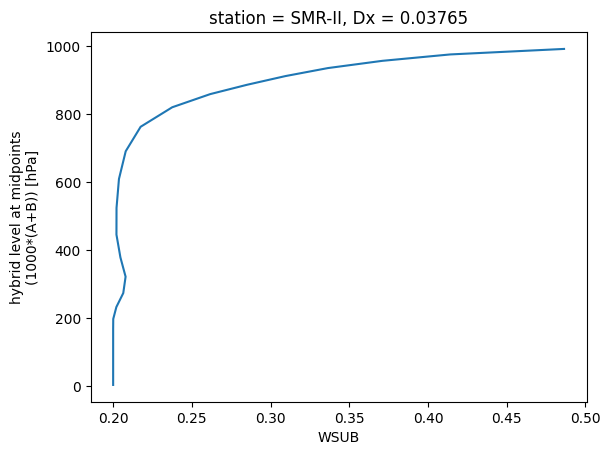

In [20]:
#plt.figure(figsize = (8,12))
#plt.subplot(3,1,1)
PeterNor['WSUB'].mean('time').plot(y = 'lev')
#plt.subplot(3,1,2)
#plt.hist(PeterNor['WSUB'].isel(lev = -2), bins = 20)
#plt.subplot(3,1,3)
#plt.hist(PeterNor['WSUB'].isel(lev = -3), bins = 20)

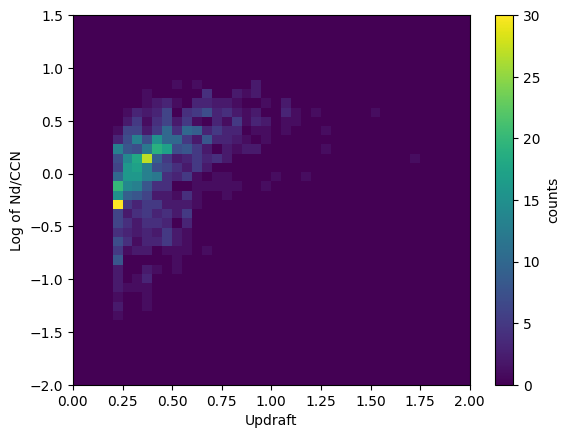

In [21]:
PeterNor['NdCCNRatio'] = PeterNor['Droplets']/PeterNor['Totaln70']


fig = plt.hist2d( PeterNor['WSUB'].isel(lev = -1),np.log10(PeterNor['NdCCNRatio'].isel(lev = -1)), bins = 40, range = [[0,2],[-2,1.5 ]]) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.xlabel('Updraft')
plt.ylabel('Log of Nd/CCN')
plt.colorbar(label='counts')

Text(0, 0.5, 'Log of Nd/CCN')

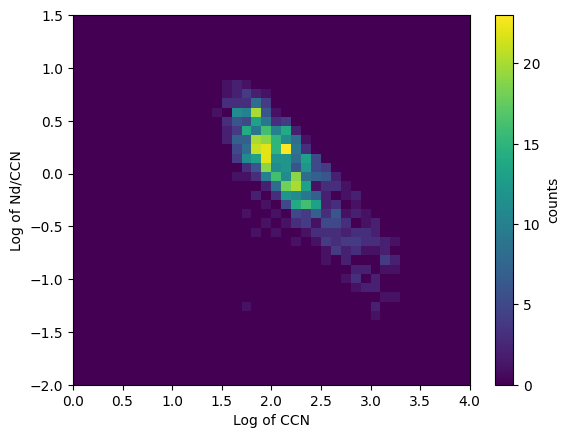

In [22]:
fig = plt.hist2d( np.log10(PeterNor['Totaln70'].isel(lev = -1)),np.log10(PeterNor['NdCCNRatio'].isel(lev = -1)), bins = 40, range = [[0,4],[-2,1.5 ]]) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)

plt.colorbar(label='counts')
plt.xlabel('Log of CCN')
plt.ylabel('Log of Nd/CCN')
#plt.xlim(1,10000)
#plt.ylim(.01,17.5)


In [15]:
def NdtoCCNGraph(x,y):
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    res = stats.linregress(np.log10(x),np.log10(y))
    lims = [1,10000]
    fig = plt.hexbin(x,y,gridsize=50, bins= 'log', xscale='log', yscale='log',edgecolors = 'face', cmap ='inferno',extent = [0,4,0,4], mincnt = 1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.plot([1,10000],[10**res.intercept*1**res.slope,10**res.intercept*10000**res.slope])
    plt.plot(lims,lims)
    plt.colorbar(label='counts')
    plt.xlabel('CCN #$cm^{-3}$')
    plt.ylabel('Nd #$cm^{-3}$')
    print(model.summary())
    
    return fig

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     16.73
Date:                Mon, 19 May 2025   Prob (F-statistic):           4.67e-05
Time:                        13:56:51   Log-Likelihood:                 85.914
No. Observations:                 980   AIC:                            -167.8
Df Residuals:                     978   BIC:                            -158.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0183      0.045     45.043      0.0

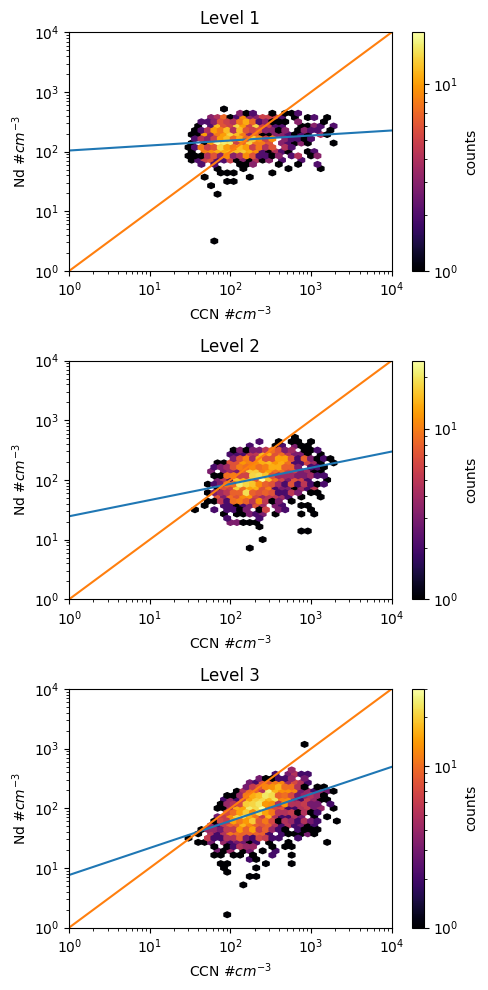

In [24]:
fig = plt.figure(figsize = (5,10))
x = PeterNor['Totaln70'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
NdtoCCNGraph(x,y)
plt.title('Level 1')
x = PeterNor['Totaln70'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)
plt.title('Level 2')
NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)
plt.title('Level 3')

NdtoCCNGraph(x,y)
plt.tight_layout()

In [33]:
def NdtoCCNGraph(x,y):
    
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    res = stats.linregress(np.log10(x),np.log10(y))
    lims = [1,10000]
    fig = plt.hexbin(x,y,gridsize=50, bins= 'log', xscale='log', yscale='log',edgecolors = 'face', cmap ='inferno',extent = [0,4,0,4], mincnt = 1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.plot([1,10000],[10**res.intercept*1**res.slope,10**res.intercept*10000**res.slope])
    plt.plot(lims,lims)
    plt.colorbar()
    
    return fig
def Susceptibility(x,y):
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    parameters = model.params
    sterrs = model.bse
    S = parameters[1]
    Sterr = sterrs[1]
    return S, Sterr
    
cm = 1/2.54
plt.figure(figsize = (8*cm,8*cm))

x =PeterNor['Totaln70'].isel(lev = -).where(PeterNor['Droplets'].isel(lev = -)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -).dropna('time')
Sus = Susceptibility(x,y)
plt.xlabel('$N_{70}$ ($ cm^{-3}$)',fontsize = 12)
plt.ylabel('$N_{D}$ ($ cm^{-3}$)',fontsize = 12)
plt.text(2,5000,f'Pressure={PeterNor.lev.isel(lev =-).values: .2f} hPa', fontsize = 11)   
plt.text(2,2500,f'S={Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 11)   
NdtoCCNGraph(x,y)

SyntaxError: f-string: expecting '=', or '!', or ':', or '}' (3563914600.py, line 40)

In [ ]:
lims = [1,10000]
plt.figure(figsize = (18,13.5))
plt.subplot(3,3,1)
x = PeterNor['Totaln70'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
NdtoCCNGraph(x,y)
plt.ylabel('Level 1, Nd #$cm^{-3}$')
plt.title('Number of Droplets vs CCN joint histograms')
plt.subplot(3,3,2)
plt.hist2d( PeterNor['WSUB'].isel(lev = -1),np.log10(PeterNor['NdCCNRatio'].isel(lev = -1)), bins = 40, range = [[0,2],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.xlabel('Updraft (m/s)')
plt.ylabel('Log of Nd/CCN')
plt.colorbar()
plt.title('Nd/CCN ratio vs Updraft Velocities')

plt.subplot(3,3,3)
plt.hist2d( np.log10(PeterNor['Totaln70'].isel(lev = -1)),np.log10(PeterNor['NdCCNRatio'].isel(lev = -1)), bins = 40, range = [[0,4],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.colorbar()
plt.xlabel('Log of CCN ($cm^{-3}$)')
plt.ylabel('Log of Nd/CCN')
plt.title('Nd/CCN ratio vs CCN')


plt.subplot(3,3,4)
x = PeterNor['Totaln70'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')

NdtoCCNGraph(x,y)
plt.ylabel('Level 2, Nd #$cm^{-3}$')

plt.subplot(3,3,5)
plt.hist2d( PeterNor['WSUB'].isel(lev = -2),np.log10(PeterNor['NdCCNRatio'].isel(lev = -2)), bins = 40, range = [[0,2],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.xlabel('Updraft (m/s)')
plt.ylabel('Log of Nd/CCN')
plt.colorbar()

plt.subplot(3,3,6)
plt.hist2d( np.log10(PeterNor['Totaln70'].isel(lev = -2)),np.log10(PeterNor['NdCCNRatio'].isel(lev = -2)), bins = 40, range = [[0,4],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.colorbar()
plt.xlabel('Log of CCN ($cm^{-3}$)')
plt.ylabel('Log of Nd/CCN')


plt.subplot(3,3,7)
x = PeterNor['Totaln70'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')

NdtoCCNGraph(x,y)
plt.ylabel('Level 3, Nd #$cm^{-3}$')


plt.subplot(3,3,8)
plt.hist2d( PeterNor['WSUB'].isel(lev = -3),np.log10(PeterNor['NdCCNRatio'].isel(lev = -3)), bins = 40, range = [[0,2],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.xlabel('Updraft (m/s)')
plt.ylabel('Log of Nd/CCN')
plt.colorbar()

plt.subplot(3,3,9)
plt.hist2d( np.log10(PeterNor['Totaln70'].isel(lev = -3)),np.log10(PeterNor['NdCCNRatio'].isel(lev = -3)), bins = 40, range = [[0,4],[-2,1.5 ]], vmax = 30) #,gridsize=50, yscale='log', xscale='log',edgecolors = 'face', cmap = 'inferno', extent = [0,4,-2,1.5 ],  bins= 'log',)
plt.colorbar()
plt.xlabel('Log of CCN ($cm^{-3}$)')
plt.ylabel('Log of Nd/CCN')
plt.tight_layout()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     34.60
Date:                Mon, 19 May 2025   Prob (F-statistic):           5.56e-09
Time:                        13:57:03   Log-Likelihood:                 94.640
No. Observations:                 980   AIC:                            -185.3
Df Residuals:                     978   BIC:                            -175.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9605      0.041     47.598      0.0

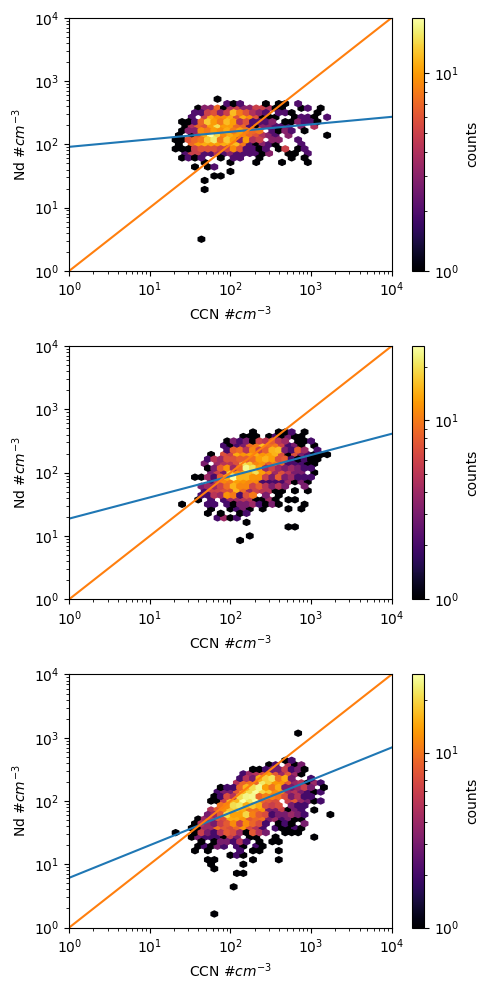

In [26]:
plt.figure(figsize = (5,10))
x = PeterNor['Totaln50'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
NdtoCCNGraph(x,y)
x = PeterNor['Totaln50'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)

NdtoCCNGraph(x,y)
x = PeterNor['Totaln50'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)

NdtoCCNGraph(x,y)
plt.tight_layout()

N150, Updraft with height, reason to exclude first level? 


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     353.3
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.60e-67
Time:                        13:57:08   Log-Likelihood:                 228.71
No. Observations:                 980   AIC:                            -453.4
Df Residuals:                     978   BIC:                            -443.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7565      0.024     72.164      0.0

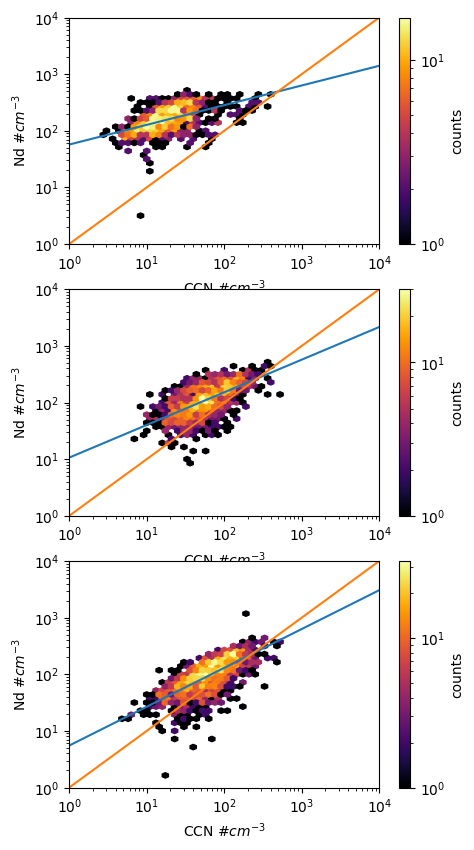

In [27]:
plt.figure(figsize = (5,10))
x = PeterNor['Totaln150'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
NdtoCCNGraph(x,y)
x = PeterNor['Totaln150'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)

NdtoCCNGraph(x,y)
x = PeterNor['Totaln150'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)

NdtoCCNGraph(x,y)

In [28]:
PeterNor_seasons = PeterNor.groupby(PeterNor['time.season'])

In [29]:
def seasonalgraph(Dataset, Season, maxlevel, maxseasonnumber):
    #plt.figure(figsize=(10,15))   
    for i in range(1,maxlevel):
        
        x = Dataset[Season]['Totaln70'].isel(lev =- i).where(Dataset[Season]['Droplets'].isel(lev =-i)>0).dropna('time')
        y = Dataset[Season]['Droplets'].isel(lev =- i).where(Dataset[Season]['Droplets'].isel(lev =-i)>0).dropna('time')
        x  =x.to_numpy()
        y = y.to_numpy()
        res = stats.linregress(np.log10(x),np.log10(y))
        Y = np.log10(y)
        X = np.log10(x)
        X = sm.add_constant(X)
        model = sm.OLS(Y,X).fit()
        print(f'{Season}')
        print('Level ' f'{i}')
        print(model.summary())
        if Season == 'DJF':
            fig = NdtoCCNGraphseason(1,i,maxlevel,x,y,res, maxseasonnumber)
        if Season == 'MAM':
            fig = NdtoCCNGraphseason(2,i,maxlevel,x,y,res, maxseasonnumber)
        if Season == 'JJA':
            fig = NdtoCCNGraphseason(3,i,maxlevel,x,y,res, maxseasonnumber)
        if Season == 'SON':
            fig = NdtoCCNGraphseason(4,i,maxlevel,x,y,res, maxseasonnumber)
    return fig

def NdtoCCNGraphseason(seasonnumber,level, maxlevel, x,y,res,maxseasonnumber):
    lims = [1,10000]
    fig = plt.subplot(maxseasonnumber,maxlevel-1,level+(seasonnumber-1)*(maxlevel-1))
    plt.hexbin(x,y,gridsize=50, bins= 'log', xscale='log', yscale='log',edgecolors = 'face', cmap ='inferno',extent = [0,4,0,4], mincnt = 1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.plot([1,10000],[10**res.intercept*1**res.slope,10**res.intercept*10000**res.slope])
    plt.plot(lims,lims)
    plt.colorbar(label='counts')
    plt.xlabel('CCN')
    plt.ylabel('Nd')
    
    return fig

DJF
Level 1
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     57.33
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.94e-13
Time:                        13:57:13   Log-Likelihood:                 86.054
No. Observations:                 476   AIC:                            -168.1
Df Residuals:                     474   BIC:                            -159.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5892      0.083     19.

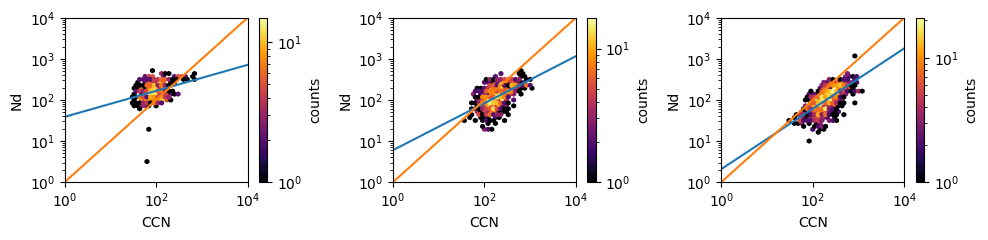

In [30]:
season = ['DJF']#, 'MAM','JJA','SON']
plt.figure(figsize = (10,2.5))
for seas in season: 
    seasonalgraph(PeterNor_seasons,seas,4,1)
    plt.tight_layout()

DJF
Level 1
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     57.33
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.94e-13
Time:                        13:57:18   Log-Likelihood:                 86.054
No. Observations:                 476   AIC:                            -168.1
Df Residuals:                     474   BIC:                            -159.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5892      0.083     19.

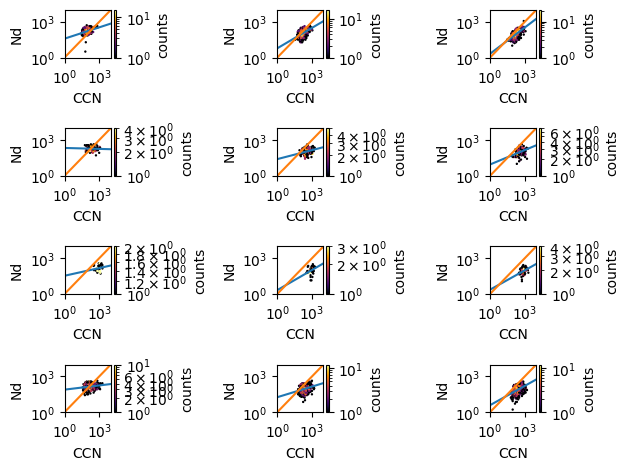

In [31]:
season = ['DJF', 'MAM','JJA','SON']
for seas in season: 
    fig = seasonalgraph(PeterNor_seasons,seas,4,4)
    #fig.tight_layout()
    plt.tight_layout()
 #   plt.savefig('plots/seasonal_fig_noresm.png')#, dpi=200)

Frequency of clouds?


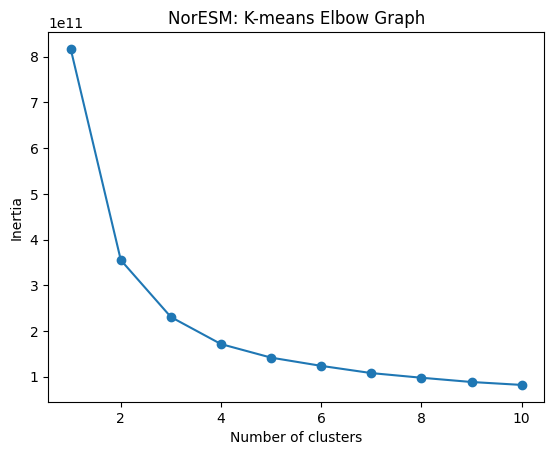

In [32]:
sizedist4clust =PeterNor['TotaldNdlogD'].isel(lev=-1)
sizedist4clust=sizedist4clust.dropna(dim='time')
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state = 2)
    kmeans.fit(sizedist4clust)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('NorESM: K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [33]:
kmeans = KMeans(n_clusters=4,random_state=2)
kmeans.fit(sizedist4clust)

myds = sizedist4clust.to_dataset()
myds['label'] = xr.DataArray(kmeans.labels_, dims=('time'))
myds

<xarray.Dataset> Size: 14MB
Dimensions:       (time: 8761, D: 200)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
    station       <U6 24B ...
    lev           float64 8B 992.6
  * D             (D) float64 2kB 0.3162 0.3331 0.3509 ... 9.493e+03 1e+04
    Dx            float64 8B 0.03765
Data variables:
    TotaldNdlogD  (time, D) float64 14MB 3.058e-13 5.696e-13 ... 1.802e-06
    label         (time) int32 35kB 3 3 3 3 3 3 3 3 3 3 ... 3 3 3 3 3 3 3 3 3 3

In [34]:
myds_med = myds['TotaldNdlogD'].groupby(myds['label']).median()

(1, 1000)

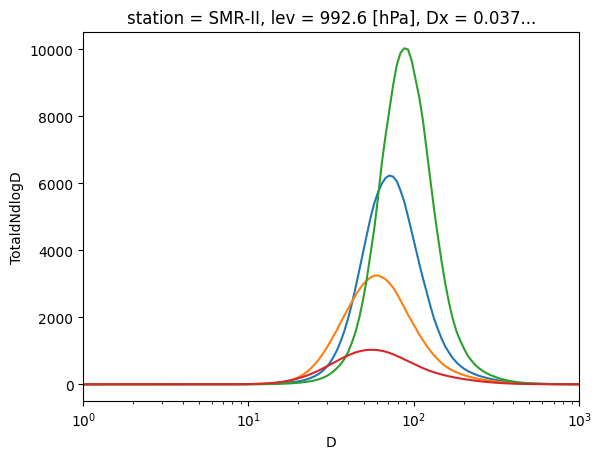

In [35]:
for l in myds_med.label:
    myds_med.sel(label=l).plot()
    plt.xscale('log')
plt.xlim([1,1000])

In [36]:
def log_distrib(Dpg,sig,Ntot,Dp):
    return Ntot * 0.39894228 / np.log10(sig) * np.exp(-0.5*(np.log10(Dp)-np.log10(Dpg))**2/(np.log10(sig)**2))

def style(ax):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.3)
        ax.spines[axis].set_color('k')
    plt.rc('axes', linewidth=0.2)
    fontsize = 12
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=8, width=1.3, pad=10, bottom=True, top=False, left=True, right=False, color='k')
    ax.tick_params(which='minor', length=4, color='k', width=1.3)
    
def plot_fit(Dp, distrib, estimate, ax):
    for i in range(len(estimate)):
        plt.plot(Dp,estimate[i], '--', label='fit mode ' + str(i), color='b')
    plt.plot(Dp,sum(estimate), label='fit', color='b', linewidth=3, alpha=0.6)
    plt.plot(Dp,distrib, color='r', label='measured', linewidth=3, alpha=0.6)
    ax.set_xscale('log')
    plt.legend()
    ax.grid(True, alpha=0.6)
    ax.set_xlabel(r'Dp ($nm$)', fontsize=15)
    style(ax)
    ax.set_ylabel(r'dN/dlogDg ($cm^{-3}$)', fontsize=15)
    ax.set_xlim([1,1000])
    ax.set_xticks([1,10,20,30,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000])
    ax.set_xticklabels([1,10,'',30,'','','','','','',100,'','','', '', '', '', '', '', 1000])

In [37]:
df = pd.DataFrame(PeterNor['TotaldNdlogD'].isel(lev = 0).mean('time'))
Dp = pd.DataFrame(PeterNor['D'])
Dp_ = Dp*1E-9
estimate = []
for l in myds_med.label:
    estimate.append(LogFit.fit_3_modes(myds_med['D']*1E-9, myds_med.sel(label = l),'yes'))

In [38]:
estimate

[[[np.float64(1.3877135757474393e-08),
   np.float64(7.000000000000002e-08),
   np.float64(7.536654796421419e-08)],
  array([1.5, 1.5, 1.5]),
  array([[   8.74288228],
         [1576.22798219],
         [1139.03978699]])],
 [[np.float64(1.4393713460022942e-07),
   np.float64(4.7627650006103146e-08),
   np.float64(6.896784891541976e-08)],
  array([1.5, 1.5, 1.5]),
  array([[126.78848227],
         [721.66068207],
         [855.00793285]])],
 [[np.float64(6.680969967026435e-08),
   np.float64(9.52553000122065e-08),
   np.float64(8.235890550984322e-08)],
  [np.float64(1.4500000000000004),
   np.float64(1.4500000000000004),
   np.float64(1.3000000000000003)],
  array([[ 411.649369  ],
         [2773.92746702],
         [ 748.17956137]])],
 [[np.float64(1.4393713460022942e-07),
   np.float64(4.0828516385164105e-08),
   np.float64(6.896784891541976e-08)],
  array([1.5, 1.5, 1.5]),
  array([[ 82.37485803],
         [272.20250201],
         [285.72151098]])]]

In [39]:
Dpg = []
Ntot = []
sig = []
for i in range(len(estimate)):
    Dpg.append(estimate[i][0])
    sig.append(estimate[i][1])
    Ntot.append(estimate[i][2])

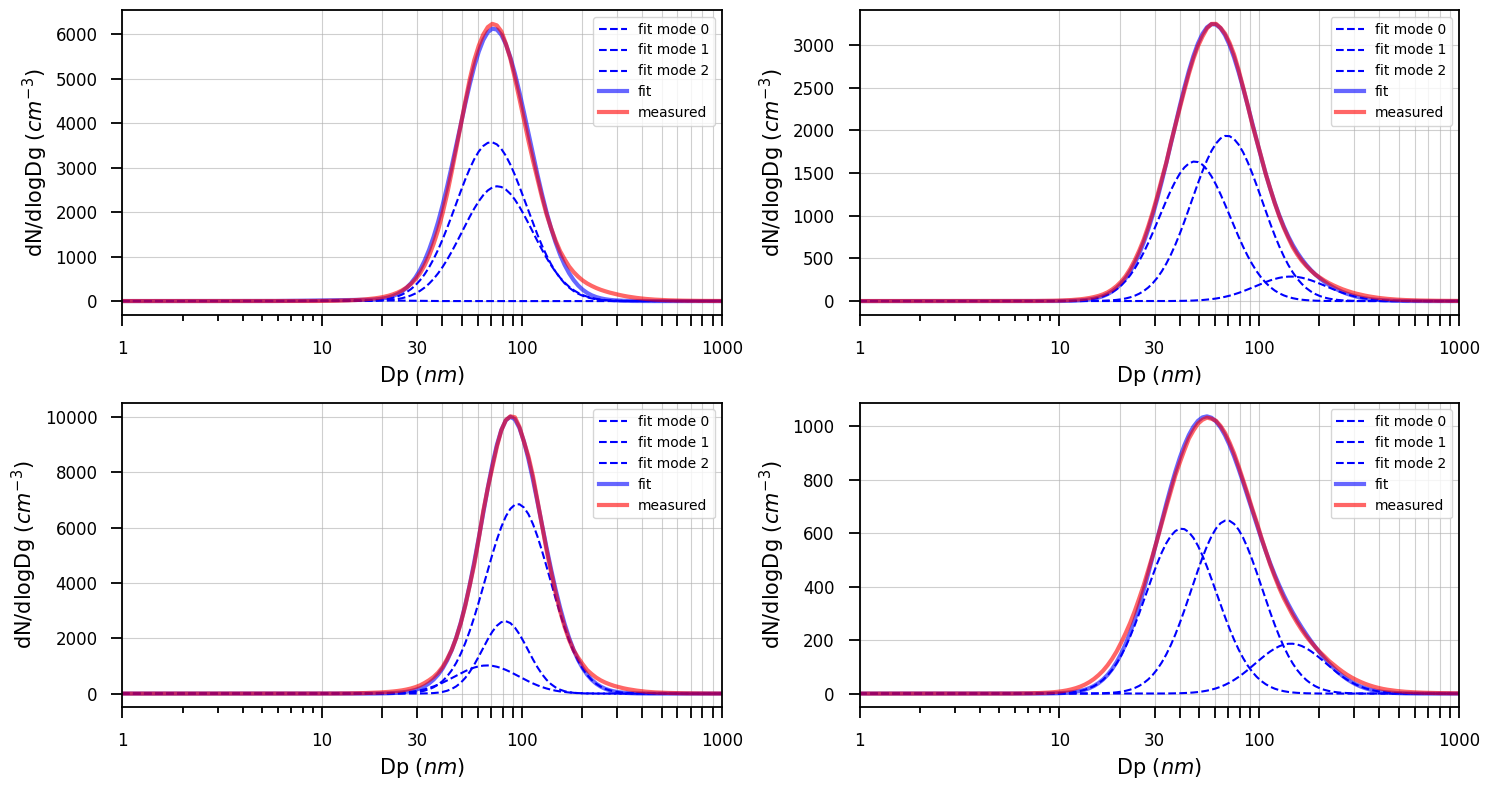

In [40]:
fig = plt.figure(num=None, figsize=(15,8))
for i in range(0,4):
    distributions = [log_distrib(Dpg[i][j],sig[i][j],Ntot[i][j],Dp_) for j in range(len(Dpg[i]))]
    ax = fig.add_subplot(2,2, i+1)
    plot_fit(Dp_*1e9, myds_med.sel(label = i), distributions, ax)
fig.tight_layout()

In [41]:
Temp_ds = PeterNor['T'].isel(lev = -1).dropna('time').groupby(myds['label']).mean()

In [42]:
DpgArray = xr.DataArray(Dpg)

NtotArray = xr.DataArray(Ntot)
NtotArray = NtotArray.squeeze()
SigArray = xr.DataArray(sig)
Means_ds = xr.Dataset({'Dpg': (['KmeansLabel','Distribution Number'], DpgArray.data), 'Ntot': (['KmeansLabel','Distribution Number'], NtotArray.data), 'Temperature':(['KmeansLabel'],Temp_ds.data), 'Sig': (['KmeansLabel','Distribution Number'], SigArray.data)})


In [43]:
!rm /share/pech2273/NorESMKmeans.nc
Means_ds.to_netcdf('/share/pech2273/NorESMKmeans.nc')

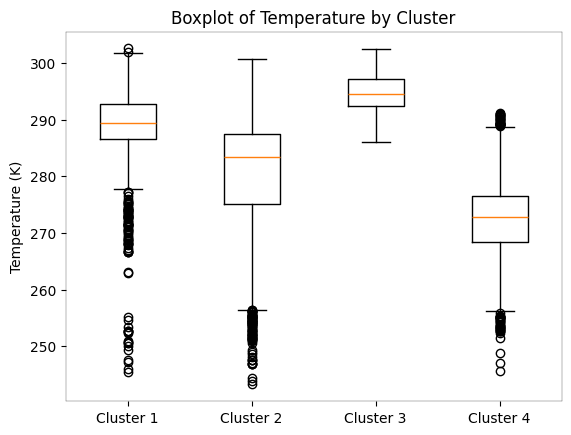

In [44]:
plt.boxplot([PeterNor['T'].isel(lev = -1).where(myds['label'] == 0, drop = True),PeterNor['T'].isel(lev = -1).where(myds['label'] == 1, drop = True), PeterNor['T'].isel(lev = -1).where(myds['label'] == 2, drop = True),\
             PeterNor['T'].isel(lev = -1).where(myds['label'] == 3, drop = True)], labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.title('Boxplot of Temperature by Cluster')
plt.ylabel('Temperature (K)')
plt.show()

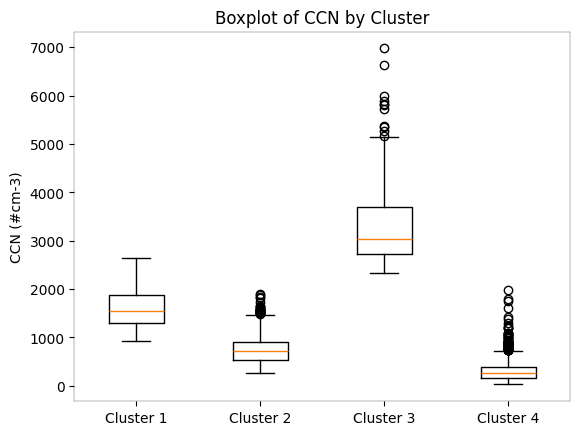

In [45]:
plt.boxplot([PeterNor['Totaln70'].isel(lev = -1).where(myds['label'] == 0, drop = True),PeterNor['Totaln70'].isel(lev = -1).where(myds['label'] == 1, drop = True), PeterNor['Totaln70'].isel(lev = -1).where(myds['label'] == 2, drop = True),\
             PeterNor['Totaln70'].isel(lev = -1).where(myds['label'] == 3, drop = True)], labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.title('Boxplot of CCN by Cluster')
plt.ylabel('CCN (#cm-3)')
plt.show()

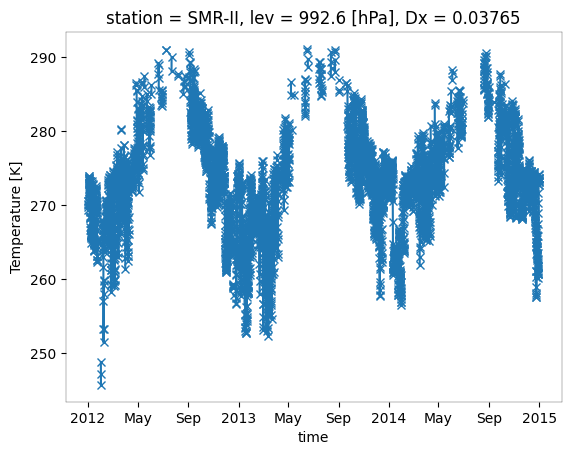

In [46]:
PeterNor['T'].isel(lev = -1).where(myds['label'] == 3).plot(marker = 'x')

(array([  2.,   1.,   0.,   6.,  15.,  17.,  50.,  82., 128., 199., 221.,
        283., 333., 406., 578., 714., 400., 339., 221., 201., 158., 107.,
         53.,  39.,  20.]),
 array([245.6628418 , 247.48054504, 249.29826355, 251.1159668 ,
        252.9336853 , 254.75138855, 256.5690918 , 258.3868103 ,
        260.20452881, 262.0222168 , 263.8399353 , 265.65765381,
        267.47537231, 269.2930603 , 271.11077881, 272.92849731,
        274.74621582, 276.56390381, 278.38162231, 280.19934082,
        282.01702881, 283.83474731, 285.65246582, 287.47015381,
        289.28787231, 291.10559082]),
 <BarContainer object of 25 artists>)

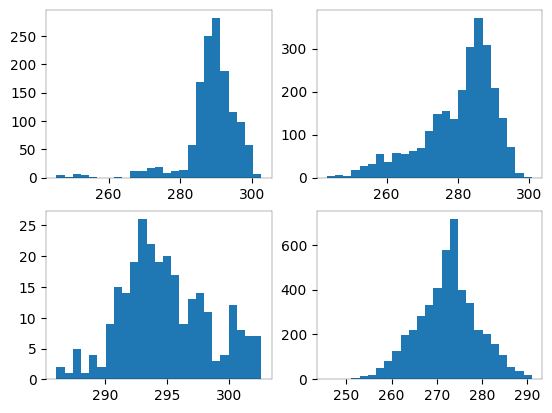

In [47]:

plt.subplot(2,2,1)
plt.hist(PeterNor['T'].isel(lev = -1).where(myds['label'] ==0), bins = 25)
plt.subplot(2,2,2)
plt.hist(PeterNor['T'].isel(lev = -1).where(myds['label'] ==1), bins = 25)
plt.subplot(2,2,3)
plt.hist(PeterNor['T'].isel(lev = -1).where(myds['label'] ==2), bins = 25)
plt.subplot(2,2,4)
plt.hist(PeterNor['T'].isel(lev = -1).where(myds['label'] ==3), bins = 25)

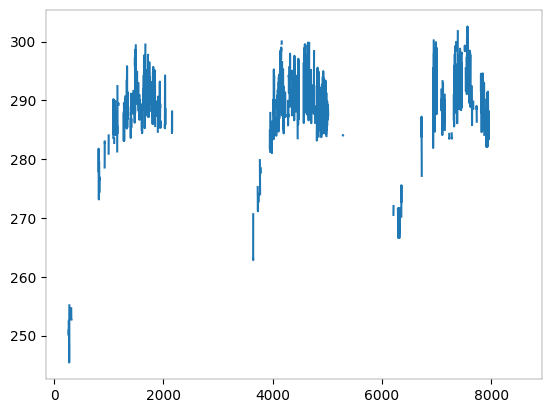

In [48]:
plt.plot(PeterNor['T'].isel(lev = -1).where(myds['label'] ==0))
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7f387b150c50>,
 'caps': [<matplotlib.lines.Line2D at 0x7f387b1537a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f3878de6f00>],
 'medians': [<matplotlib.lines.Line2D at 0x7f387b152ab0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f387b152d20>],
 'means': []}

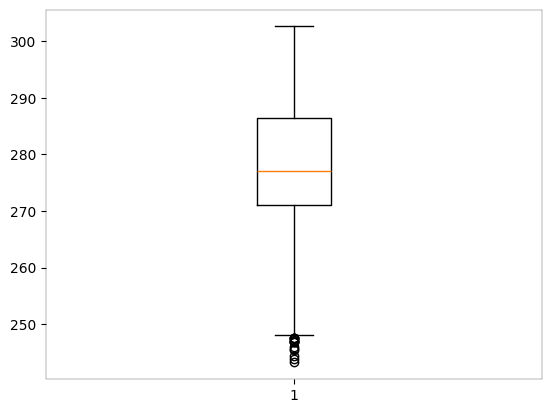

In [49]:
plt.boxplot(PeterNor['T'].isel(lev = -1))

In [50]:
myds['time_of_day'] = myds['time.hour'] 
myds['day_of_year'] = myds['time.dayofyear'] 


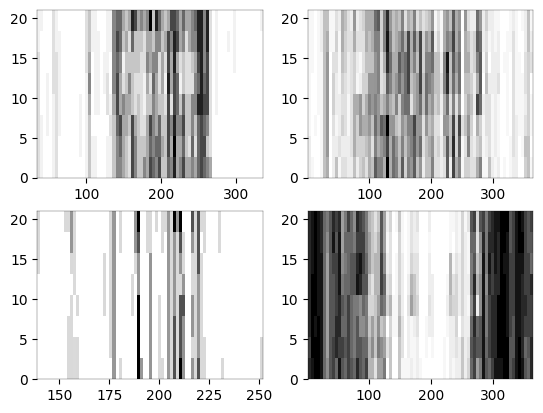

In [51]:

plt.subplot(2,2,1)
plt.hist2d(myds['day_of_year'].where(myds['label'] ==0, drop = 'true'), myds['time_of_day'].where(myds['label'] ==0, drop = 'true'), bins = [75,8], density = 'true', cmap = 'Greys')
plt.subplot(2,2,2)
plt.hist2d(myds['day_of_year'].where(myds['label'] ==1, drop = 'true'), myds['time_of_day'].where(myds['label'] ==1, drop = 'true'), bins = [75,8], density = 'true', cmap = 'Greys')
plt.subplot(2,2,3)
plt.hist2d(myds['day_of_year'].where(myds['label'] ==2, drop = 'true'), myds['time_of_day'].where(myds['label'] ==2, drop = 'true'), bins = [75,8], density = 'true', cmap = 'Greys')
plt.subplot(2,2,4)
plt.hist2d(myds['day_of_year'].where(myds['label'] ==3, drop = 'true'), myds['time_of_day'].where(myds['label'] ==3, drop = 'true'), bins = [75,8], density = 'true', cmap = 'Greys')
plt.show()

In [52]:
NorMassFrac_ds = xr.open_dataset('/share/pech2273/NorMassFrac.nc')

In [53]:
BCNorMassFracMeans = NorMassFrac_ds['BCMassFrac'].dropna('time').isel(lev = -1).groupby(myds['label']).mean()
OANorMassFracMeans = NorMassFrac_ds['OAMassFrac'].dropna('time').isel(lev = -1).groupby(myds['label']).mean()
SO4NorMassFracMeans = NorMassFrac_ds['SO4MassFrac'].dropna('time').isel(lev = -1).groupby(myds['label']).mean()
SeasaltNorMassFracMeans = NorMassFrac_ds['SeasaltMassFrac'].dropna('time').isel(lev = -1).groupby(myds['label']).mean()
DustNorMassFracMeans = NorMassFrac_ds['DustMassFrac'].dropna('time').isel(lev = -1).groupby(myds['label']).mean()

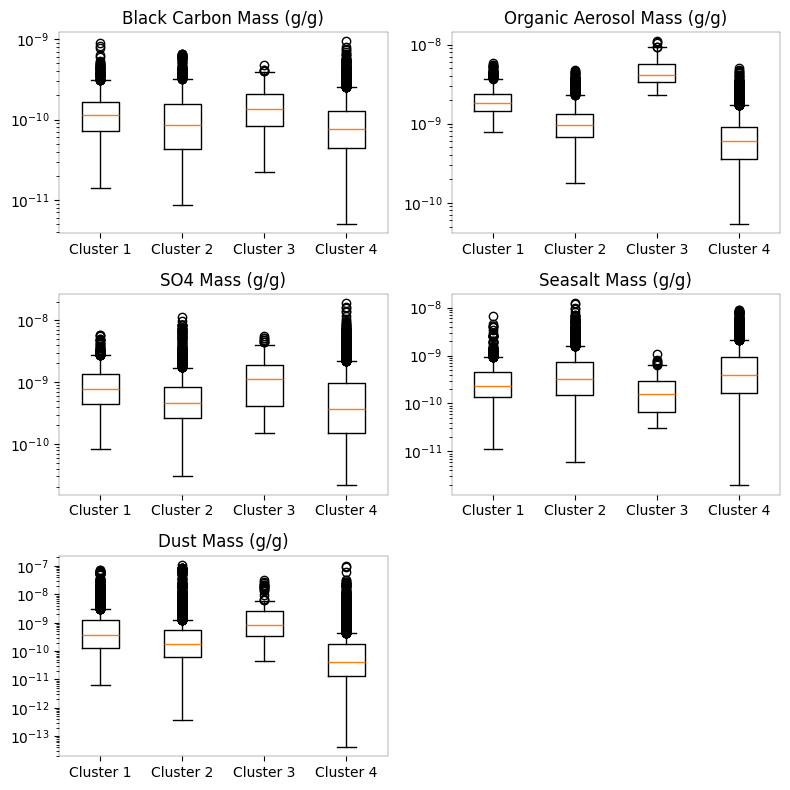

In [54]:
plt.figure(figsize = (8,8))
plt.subplot(3,2,1)
plt.title('Black Carbon Mass (g/g)')
plt.boxplot([NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.yscale('log')
plt.subplot(3,2,2)
plt.title('Organic Aerosol Mass (g/g)')
plt.boxplot([NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.yscale('log')
plt.subplot(3,2,3)
plt.yscale('log')
plt.title('SO4 Mass (g/g)')
plt.boxplot([NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,4)
plt.yscale('log')
plt.title('Seasalt Mass (g/g)')
plt.boxplot([NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,5)
plt.yscale('log')
plt.title('Dust Mass (g/g)')
plt.boxplot([NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.tight_layout()
plt.show()

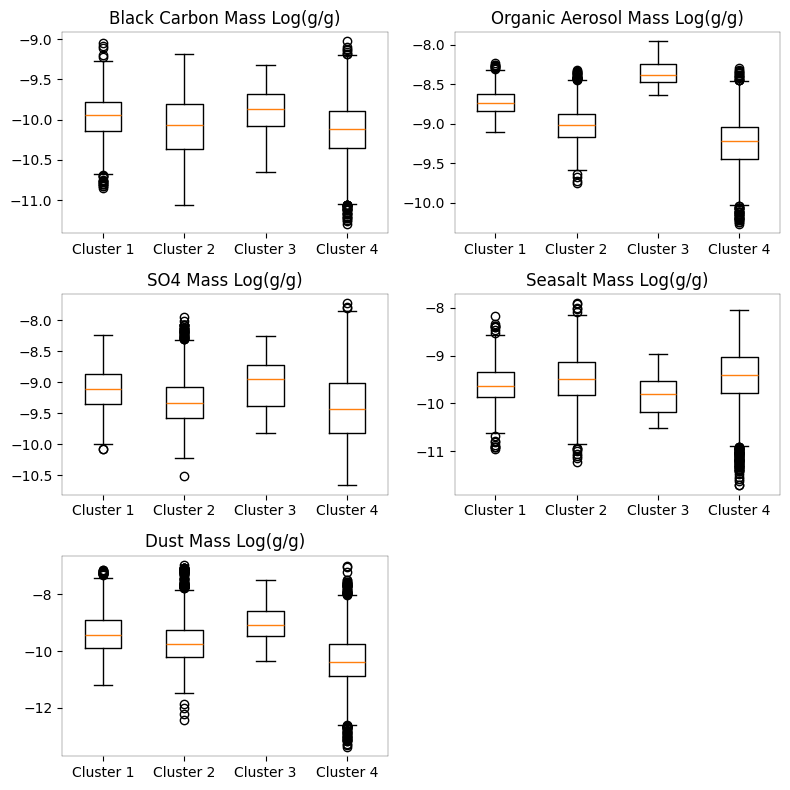

In [55]:
plt.figure(figsize = (8,8))
plt.subplot(3,2,1)
plt.title('Black Carbon Mass Log(g/g)')
plt.boxplot([np.log10(NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True)),np.log10(NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True)),\
            np.log10(NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True)),np.log10(NorMassFrac_ds['BCMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True))],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,2)
plt.title('Organic Aerosol Mass Log(g/g)')
plt.boxplot([np.log10(NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True)),np.log10(NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True)),\
            np.log10(NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True)),np.log10(NorMassFrac_ds['OAMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True))],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,3)
plt.title('SO4 Mass Log(g/g)')
plt.boxplot([np.log10(NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True)),np.log10(NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True)),\
            np.log10(NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True)),np.log10(NorMassFrac_ds['SO4Mass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True))],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,4)
plt.title('Seasalt Mass Log(g/g)')
plt.boxplot([np.log10(NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True)),np.log10(NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True)),\
            np.log10(NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True)),np.log10(NorMassFrac_ds['SeasaltMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True))],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,5)
plt.title('Dust Mass Log(g/g)')
plt.boxplot([np.log10(NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True)),np.log10(NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True)),\
            np.log10(NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True)),np.log10(NorMassFrac_ds['DustMass'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True))],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.tight_layout()
plt.show()

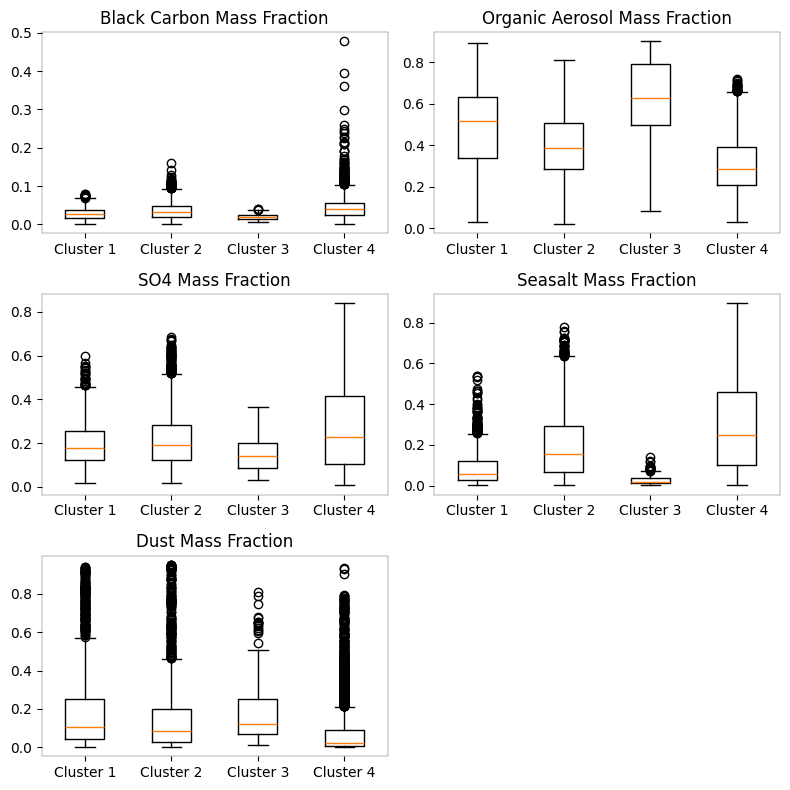

In [56]:
plt.figure(figsize = (8,8))
plt.subplot(3,2,1)
plt.title('Black Carbon Mass Fraction')
plt.boxplot([NorMassFrac_ds['BCMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['BCMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['BCMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['BCMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,2)
plt.title('Organic Aerosol Mass Fraction')
plt.boxplot([NorMassFrac_ds['OAMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['OAMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['OAMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['OAMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,3)
plt.title('SO4 Mass Fraction')
plt.boxplot([NorMassFrac_ds['SO4MassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['SO4MassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['SO4MassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['SO4MassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,4)
plt.title('Seasalt Mass Fraction')
plt.boxplot([NorMassFrac_ds['SeasaltMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['SeasaltMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['SeasaltMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['SeasaltMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.subplot(3,2,5)
plt.title('Dust Mass Fraction')
plt.boxplot([NorMassFrac_ds['DustMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 0, drop = True),NorMassFrac_ds['DustMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 1, drop = True),\
            NorMassFrac_ds['DustMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 2, drop = True),NorMassFrac_ds['DustMassFrac'].dropna('time').isel(lev = -1).where(myds['label'] == 3, drop = True)],\
           labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
plt.tight_layout()
plt.show()

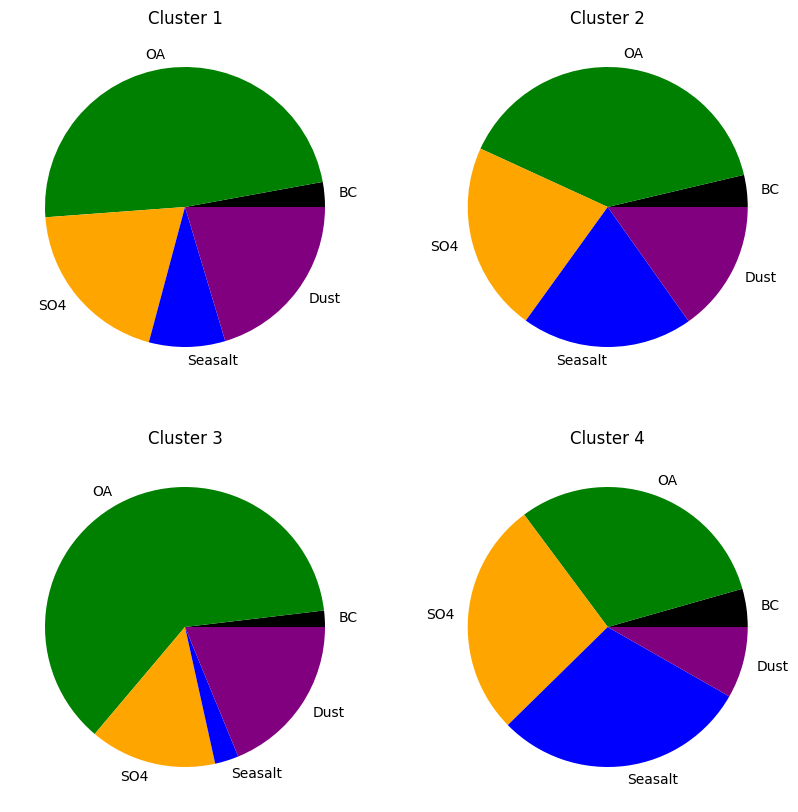

In [57]:
plt.figure(figsize = (10,10))
for i in range(1,5):
    plt.subplot(2,2,i)
    plt.title(f'Cluster {i}')
    plt.pie([BCNorMassFracMeans[i-1],OANorMassFracMeans[i-1],SO4NorMassFracMeans[i-1], SeasaltNorMassFracMeans[i-1], DustNorMassFracMeans[i-1]], labels = ['BC','OA','SO4','Seasalt', 'Dust'],colors=['black', 'green','orange','blue','purple'])
plt.show()

In [58]:
SeasaltNorMassFracMeans

<xarray.DataArray 'SeasaltMassFrac' (label: 4)> Size: 32B
array([0.0879807 , 0.1975532 , 0.02742258, 0.29396105])
Coordinates:
    station  <U6 24B ...
    lev      float64 8B 992.6
  * label    (label) int32 16B 0 1 2 3

In [59]:
NorMassFracMeans_ds = xr.Dataset({'BCMassFrac' : BCNorMassFracMeans, 'OAMassFrac' :OANorMassFracMeans,'SO4MassFrac' : SO4NorMassFracMeans, 'SeasaltMassFrac' :SeasaltNorMassFracMeans, 'DustMassFrac' :DustNorMassFracMeans})

In [60]:
#estimate.to_netcdf('/share/pech2273/NorDistibutionforPARSEC.nc')
!rm /share/pech2273/NorMassFracforPARSEC.nc
NorMassFracMeans_ds.to_netcdf('/share/pech2273/NorMassFracforPARSEC.nc')

In [61]:
print(len(myds.where(myds['label']==0)))

4


In [62]:
''' 
This is the with the Mode 14 missing
Activated_Radius = [np.float64(171.27179794508717),
 np.float64(129.7681272383768),
 np.float64(226.04956544882387),
 np.float64(82.88680612635326),
 np.float64(127.02740777196964),
 np.float64(92.22282316159196),
 np.float64(174.96712605504354),
 np.float64(60.17642489833283),
 np.float64(107.08598197131427),
 np.float64(79.42261867825579),
 np.float64(147.49987294031467),
 np.float64(50.72961548053402)]
Activated_RadiusCC = [np.float64(167.65451563806593),
 np.float64(121.71839935273819),
 np.float64(221.2753696768497),
 np.float64(74.49590453102621),
 np.float64(119.14769117018751),
 np.float64(82.88680612635326),
 np.float64(171.27179794508717),
 np.float64(54.08456923060725),
 np.float64(98.3218898207321),
 np.float64(68.39903769437733),
 np.float64(138.3502160437893),
 np.float64(46.57782066434512)]
 '''

' \nThis is the with the Mode 14 missing\nActivated_Radius = [np.float64(171.27179794508717),\n np.float64(129.7681272383768),\n np.float64(226.04956544882387),\n np.float64(82.88680612635326),\n np.float64(127.02740777196964),\n np.float64(92.22282316159196),\n np.float64(174.96712605504354),\n np.float64(60.17642489833283),\n np.float64(107.08598197131427),\n np.float64(79.42261867825579),\n np.float64(147.49987294031467),\n np.float64(50.72961548053402)]\nActivated_RadiusCC = [np.float64(167.65451563806593),\n np.float64(121.71839935273819),\n np.float64(221.2753696768497),\n np.float64(74.49590453102621),\n np.float64(119.14769117018751),\n np.float64(82.88680612635326),\n np.float64(171.27179794508717),\n np.float64(54.08456923060725),\n np.float64(98.3218898207321),\n np.float64(68.39903769437733),\n np.float64(138.3502160437893),\n np.float64(46.57782066434512)]\n '

In [63]:
## With Mode 14

Activated_Radius = [np.float64(212.0273434344203),
 np.float64(174.96712605504354),
 np.float64(273.9296799762329),
 np.float64(119.14769117018751),
 np.float64(164.11363079662692),
 np.float64(124.34457265169122),
 np.float64(226.04956544882387),
 np.float64(81.13622616582478),
 np.float64(141.33523429255584),
 np.float64(102.61040941702),
 np.float64(194.67467838811976),
 np.float64(66.95444125855037)]
Activated_RadiusCC = [np.float64(207.54929878718698),
 np.float64(171.27179794508717),
 np.float64(262.4810091517297),
 np.float64(114.16800917360587),
 np.float64(164.11363079662692),
 np.float64(119.14769117018751),
 np.float64(216.60200553100083),
 np.float64(74.49590453102621),
 np.float64(138.3502160437893),
 np.float64(96.24531891583946),
 np.float64(190.56312424898383),
 np.float64(60.17642489833283)]

In [64]:
CDNC_ds = xr.open_dataset('/share/pech2273/NorCDNCParsec.nc')
myds['Tot_dis'] = PeterNor['TotaldNdlogD']
myds['Droplets'] = PeterNor['Droplets']
myds['DropletsCCUp1'] = PeterNor['Droplets']
myds['DropletsCCUp2'] = PeterNor['Droplets']
myds['DropletsCCUp3'] = PeterNor['Droplets']
myds['ActivatedNumberUpdraft1'] = PeterNor['Totaln70']
myds['ActivatedNumberUpdraft1CC']= PeterNor['Totaln70']
myds['ActivatedNumberUpdraft2']= PeterNor['Totaln70']
myds['ActivatedNumberUpdraft2CC']= PeterNor['Totaln70']
myds['ActivatedNumberUpdraft3']= PeterNor['Totaln70']
myds['ActivatedNumberUpdraft3CC']= PeterNor['Totaln70']
myds['T'] = PeterNor['T']
myds['TotN70'] = PeterNor['Totaln70']

In [65]:
for i in range(4):
    mask = myds['label'] == i  
    myds['DropletsCCUp1'] = xr.where( mask, PeterNor['Droplets']*(1+CDNC_ds['Percentage_Increase'][i]/100), myds['DropletsCCUp1'])
for i in range(4):
    mask = myds['label'] == i  
    myds['DropletsCCUp2'] = xr.where(mask, PeterNor['Droplets']* (1+CDNC_ds['Percentage_Increase'][i+4]/100), myds['DropletsCCUp2'])
for i in range(4):
    mask = myds['label'] == i  
    myds['DropletsCCUp3'] = xr.where(mask, PeterNor['Droplets']* (1+CDNC_ds['Percentage_Increase'][i+8]/100), myds['DropletsCCUp3'])
    

In [66]:
for i in range(4):
    mask = myds['label'] == i  
    myds['ActivatedNumberUpdraft1'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_Radius[i]).sum('D')*deltax, myds['ActivatedNumberUpdraft1'])
    myds['ActivatedNumberUpdraft1CC'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_RadiusCC[i]).sum('D')*deltax, myds['ActivatedNumberUpdraft1CC'])

for i in range(4):
    mask = myds['label'] == i  
    myds['ActivatedNumberUpdraft2'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_Radius[i+4]).sum('D')*deltax, myds['ActivatedNumberUpdraft2'])
    myds['ActivatedNumberUpdraft2CC'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_RadiusCC[i+4]).sum('D')*deltax, myds['ActivatedNumberUpdraft2CC'])

for i in range(4):
    mask = myds['label'] == i  
    myds['ActivatedNumberUpdraft3'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_Radius[i+8]).sum('D')*deltax, myds['ActivatedNumberUpdraft3'])
    myds['ActivatedNumberUpdraft3CC'] = xr.where( mask, PeterNor['TotaldNdlogD'].where(PeterNor['D']>Activated_RadiusCC[i+8]).sum('D')*deltax, myds['ActivatedNumberUpdraft3CC'])

    

In [67]:
myds

<xarray.Dataset> Size: 487MB
Dimensions:                    (time: 8761, lev: 32, D: 200)
Coordinates:
  * time                       (time) datetime64[ns] 70kB 2012-01-02 ... 2015...
    station                    <U6 24B 'SMR-II'
  * lev                        (lev) float64 256B 3.643 7.595 ... 976.3 992.6
  * D                          (D) float64 2kB 0.3162 0.3331 ... 9.493e+03 1e+04
    Dx                         float64 8B 0.03765
    index                      <U19 76B 'Cluster 1 Updraft 1'
Data variables: (12/17)
    TotaldNdlogD               (time, D) float64 14MB 3.058e-13 ... 1.802e-06
    label                      (time) int32 35kB 3 3 3 3 3 3 3 ... 3 3 3 3 3 3 3
    time_of_day                (time) int64 70kB 0 3 6 9 12 15 ... 12 15 18 21 0
    day_of_year                (time) int64 70kB 2 2 2 2 2 ... 365 365 365 365 1
    Tot_dis                    (time, lev, D) float64 449MB 4.841e-19 ... 1.8...
    Droplets                   (time, lev) float32 1MB dask.array<chunksize=(100, 32), meta=np.ndarray>
    ...                         ...
    ActivatedNumberUpdraft2    (time, lev) float64 2MB 0.0293 0.03728 ... 61.97
    ActivatedNumberUpdraft2CC  (time, lev) float64 2MB 0.04157 0.05334 ... 83.51
    ActivatedNumberUpdraft3    (time, lev) float64 2MB 0.05585 0.07231 ... 109.1
    ActivatedNumberUpdraft3CC  (time, lev) float64 2MB 0.07126 0.09308 ... 137.7
    T                          (time, lev) float32 1MB dask.array<chunksize=(100, 32), meta=np.ndarray>
    TotN70                     (time, lev) float64 2MB 0.04851 0.06252 ... 95.83

In [68]:
!rm /share/pech2273/NorESMProcessed.nc
myds.to_netcdf('/share/pech2273/NorESMProcessed.nc')

In [69]:
def Susceptibility(x, y):
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    parameters = model.params
    sterrs = model.bse
    S = parameters[1]
    Sterr = sterrs[1]
    return S, Sterr

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     16.67
Date:                Mon, 19 May 2025   Prob (F-statistic):           4.81e-05
Time:                        13:59:52   Log-Likelihood:                 85.950
No. Observations:                 980   AIC:                            -167.9
Df Residuals:                     978   BIC:                            -158.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0435      0.045     45.608      0.0

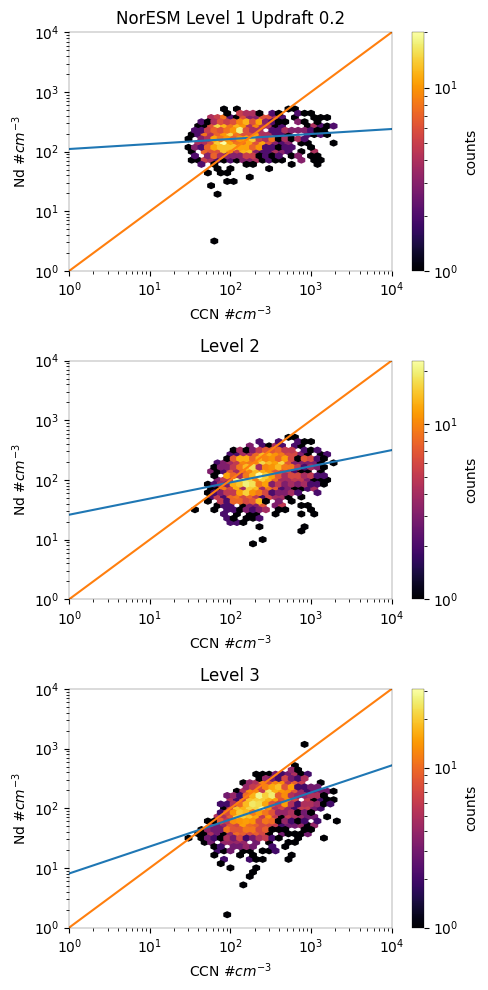

In [70]:
plt.figure(figsize = (5,10))
x = PeterNor['Totaln70'].isel(lev = -1).where(myds['DropletsCCUp1'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -1).where(myds['DropletsCCUp1'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
NdtoCCNGraph(x,y)
SCCUp1Lev1 = Susceptibility(x,y)
plt.title('NorESM Level 1 Updraft 0.2')
x = PeterNor['Totaln70'].isel(lev = -2).where(myds['DropletsCCUp1'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -2).where(myds['DropletsCCUp1'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)
SCCUp1Lev2 = Susceptibility(x,y)
plt.title('Level 2')

NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -3).where(myds['DropletsCCUp1'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -3).where(myds['DropletsCCUp1'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)
SCCUp1Lev3 = Susceptibility(x,y)
plt.title('Level 3')

NdtoCCNGraph(x,y)
plt.tight_layout()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     16.23
Date:                Mon, 19 May 2025   Prob (F-statistic):           6.05e-05
Time:                        14:00:06   Log-Likelihood:                 85.359
No. Observations:                 980   AIC:                            -166.7
Df Residuals:                     978   BIC:                            -156.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0481      0.045     45.683      0.0

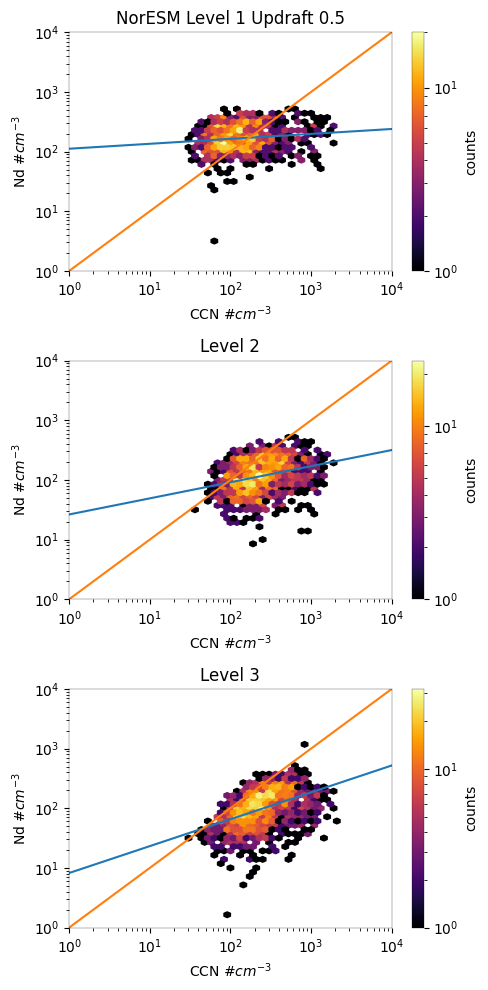

In [71]:
plt.figure(figsize = (5,10))
x = PeterNor['Totaln70'].isel(lev = -1).where(myds['DropletsCCUp2'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -1).where(myds['DropletsCCUp2'].isel(lev =-1)>0).dropna('time')
SCCUp2Lev1 = Susceptibility(x,y)

plt.subplot(3,1,1)
plt.title('NorESM Level 1 Updraft 0.5')

NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -2).where(myds['DropletsCCUp2'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -2).where(myds['DropletsCCUp2'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)
SCCUp2Lev2 = Susceptibility(x,y)
plt.title('Level 2')


NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -3).where(myds['DropletsCCUp2'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -3).where(myds['DropletsCCUp2'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)
SCCUp2Lev3 = Susceptibility(x,y)
plt.title('Level 3')

NdtoCCNGraph(x,y)
plt.tight_layout()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     17.85
Date:                Mon, 19 May 2025   Prob (F-statistic):           2.61e-05
Time:                        14:00:19   Log-Likelihood:                 86.366
No. Observations:                 980   AIC:                            -168.7
Df Residuals:                     978   BIC:                            -159.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0346      0.045     45.429      0.0

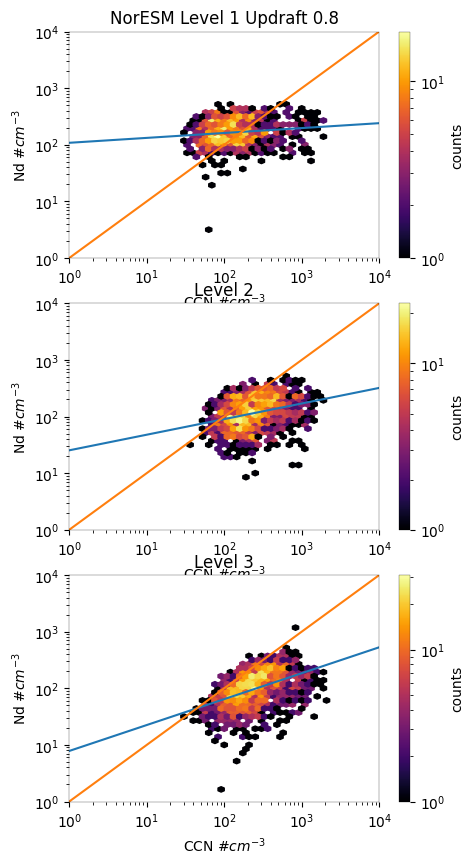

In [72]:
plt.figure(figsize = (5,10))
x = PeterNor['Totaln70'].isel(lev = -1).where(myds['DropletsCCUp3'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -1).where(myds['DropletsCCUp3'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
SCCUp3Lev1 = Susceptibility(x,y)
plt.title('NorESM Level 1 Updraft 0.8')

NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -2).where(myds['DropletsCCUp3'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -2).where(myds['DropletsCCUp3'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)
SCCUp3Lev2 = Susceptibility(x,y)
plt.title('Level 2')

NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -3).where(myds['DropletsCCUp3'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -3).where(myds['DropletsCCUp3'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)
SCCUp3Lev3 = Susceptibility(x,y)
plt.title('Level 3')

NdtoCCNGraph(x,y)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     16.73
Date:                Mon, 19 May 2025   Prob (F-statistic):           4.67e-05
Time:                        14:00:29   Log-Likelihood:                 85.914
No. Observations:                 980   AIC:                            -167.8
Df Residuals:                     978   BIC:                            -158.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0183      0.045     45.043      0.0

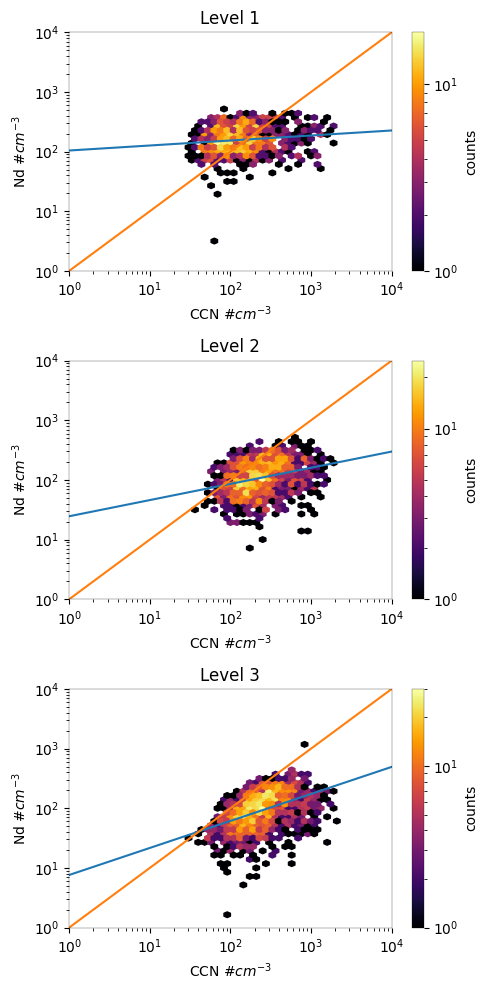

In [73]:
fig = plt.figure(figsize = (5,10))
x = PeterNor['Totaln70'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
plt.subplot(3,1,1)
SBaseLev1 = Susceptibility(x,y)

NdtoCCNGraph(x,y)
plt.title('Level 1')
x = PeterNor['Totaln70'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
plt.subplot(3,1,2)
plt.title('Level 2')
SBaseLev2 = Susceptibility(x,y)

NdtoCCNGraph(x,y)
x = PeterNor['Totaln70'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
plt.subplot(3,1,3)
plt.title('Level 3')
SBaseLev3 = Susceptibility(x,y)

NdtoCCNGraph(x,y)
plt.tight_layout()

In [74]:
ArrayList = [SBaseLev1, SCCUp1Lev1, SCCUp2Lev1, SCCUp3Lev1]
SusceptibilityLev1_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityLev1_df = SusceptibilityLev1_df.T
SusceptibilityLev1_df.columns = ['Base', 'CC & Updraft 1', 'CC & Updraft 2', 'CC & Updraft 3']
SusceptibilityLev1_df.index = ['Susceptibility', 'Standard Error']
SusceptibilityLev1_df

,Base,CC & Updraft 1,CC & Updraft 2,CC & Updraft 3
Susceptibility,0.083944,0.083798,0.082729,0.086684
Standard Error,0.020524,0.020524,0.020536,0.020515


In [75]:
ArrayList = [SBaseLev2, SCCUp1Lev2, SCCUp2Lev2, SCCUp3Lev2]
SusceptibilityLev2_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityLev2_df = SusceptibilityLev2_df.T
SusceptibilityLev2_df.columns = ['Base', 'CC & Updraft 1', 'CC & Updraft 2', 'CC & Updraft 3']
SusceptibilityLev2_df.index = ['Susceptibility', 'Standard Error']
SusceptibilityLev2_df

,Base,CC & Updraft 1,CC & Updraft 2,CC & Updraft 3
Susceptibility,0.271117,0.270677,0.269895,0.275596
Standard Error,0.024056,0.024055,0.024071,0.024047


In [76]:
ArrayList = [SBaseLev3, SCCUp1Lev3, SCCUp2Lev3, SCCUp3Lev3]
SusceptibilityLev3_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityLev3_df = SusceptibilityLev3_df.T
SusceptibilityLev3_df.columns = ['Base', 'CC & Updraft 1', 'CC & Updraft 2', 'CC & Updraft 3']
SusceptibilityLev3_df.index = ['Susceptibility', 'Standard Error']
SusceptibilityLev3_df

,Base,CC & Updraft 1,CC & Updraft 2,CC & Updraft 3
Susceptibility,0.453035,0.452886,0.450511,0.457815
Standard Error,0.021470,0.021466,0.021493,0.021465


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     269.5
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.12e-53
Time:                        14:00:35   Log-Likelihood:                 196.86
No. Observations:                 980   AIC:                            -389.7
Df Residuals:                     978   BIC:                            -379.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6350      0.035     46.780      0.0

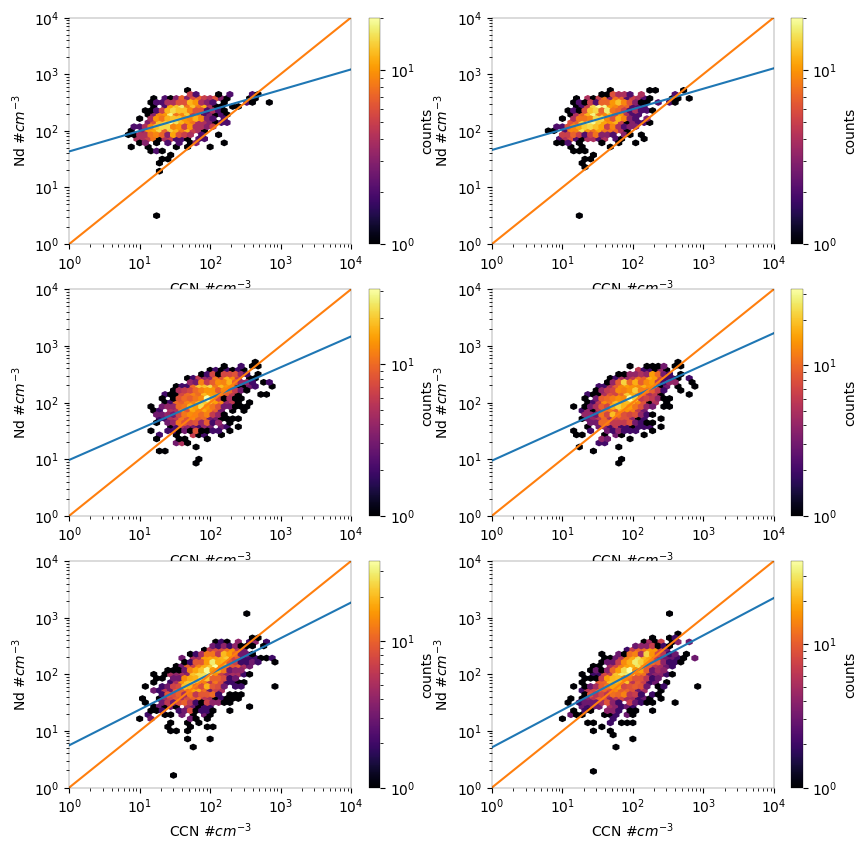

In [77]:
plt.figure(figsize = (10,10))

x = myds['ActivatedNumberUpdraft1'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,1)
NdtoCCNGraph(x,y)
SActUp1Lev1 = Susceptibility(x,y)
x = myds['ActivatedNumberUpdraft1CC'].isel(lev = -1).where(myds['DropletsCCUp1'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -1).where(myds['DropletsCCUp1'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,2)
NdtoCCNGraph(x,y)
SActCCUp1Lev1 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft1'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,3)
SActUp1Lev2 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft1CC'].isel(lev = -2).where(myds['DropletsCCUp1'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -2).where(myds['DropletsCCUp1'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,4)
NdtoCCNGraph(x,y)
SActCCUp1Lev2 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft1'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,5)
SActUp1Lev3 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft1CC'].isel(lev = -3).where(myds['DropletsCCUp1'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp1'].isel(lev = -3).where(myds['DropletsCCUp1'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,6)
NdtoCCNGraph(x,y)
SActCCUp1Lev3 = Susceptibility(x,y)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     63.61
Date:                Mon, 19 May 2025   Prob (F-statistic):           4.21e-15
Time:                        14:00:54   Log-Likelihood:                 108.48
No. Observations:                 980   AIC:                            -213.0
Df Residuals:                     978   BIC:                            -203.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8228      0.048     38.215      0.0

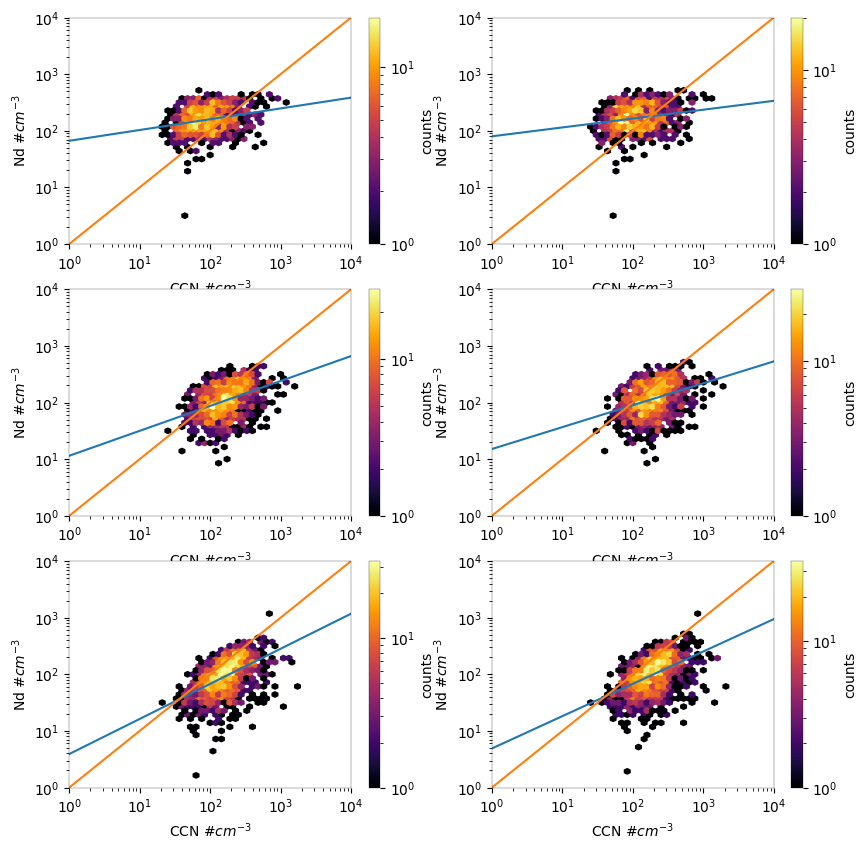

In [78]:
plt.figure(figsize = (10,10))

x = myds['ActivatedNumberUpdraft2'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,1)
NdtoCCNGraph(x,y)
SActUp2Lev1 = Susceptibility(x,y)
x = myds['ActivatedNumberUpdraft2CC'].isel(lev = -1).where(myds['DropletsCCUp2'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -1).where(myds['DropletsCCUp2'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,2)
NdtoCCNGraph(x,y)
SActCCUp2Lev1 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft2'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,3)
SActUp2Lev2 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft2CC'].isel(lev = -2).where(myds['DropletsCCUp2'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -2).where(myds['DropletsCCUp2'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,4)
NdtoCCNGraph(x,y)
SActCCUp2Lev2 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft2'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,5)
SActUp2Lev3 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft2CC'].isel(lev = -3).where(myds['DropletsCCUp2'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp2'].isel(lev = -3).where(myds['DropletsCCUp2'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,6)
NdtoCCNGraph(x,y)
SActCCUp2Lev3 = Susceptibility(x,y)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     24.08
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.08e-06
Time:                        14:01:12   Log-Likelihood:                 89.524
No. Observations:                 980   AIC:                            -175.0
Df Residuals:                     978   BIC:                            -165.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9405      0.053     36.478      0.0

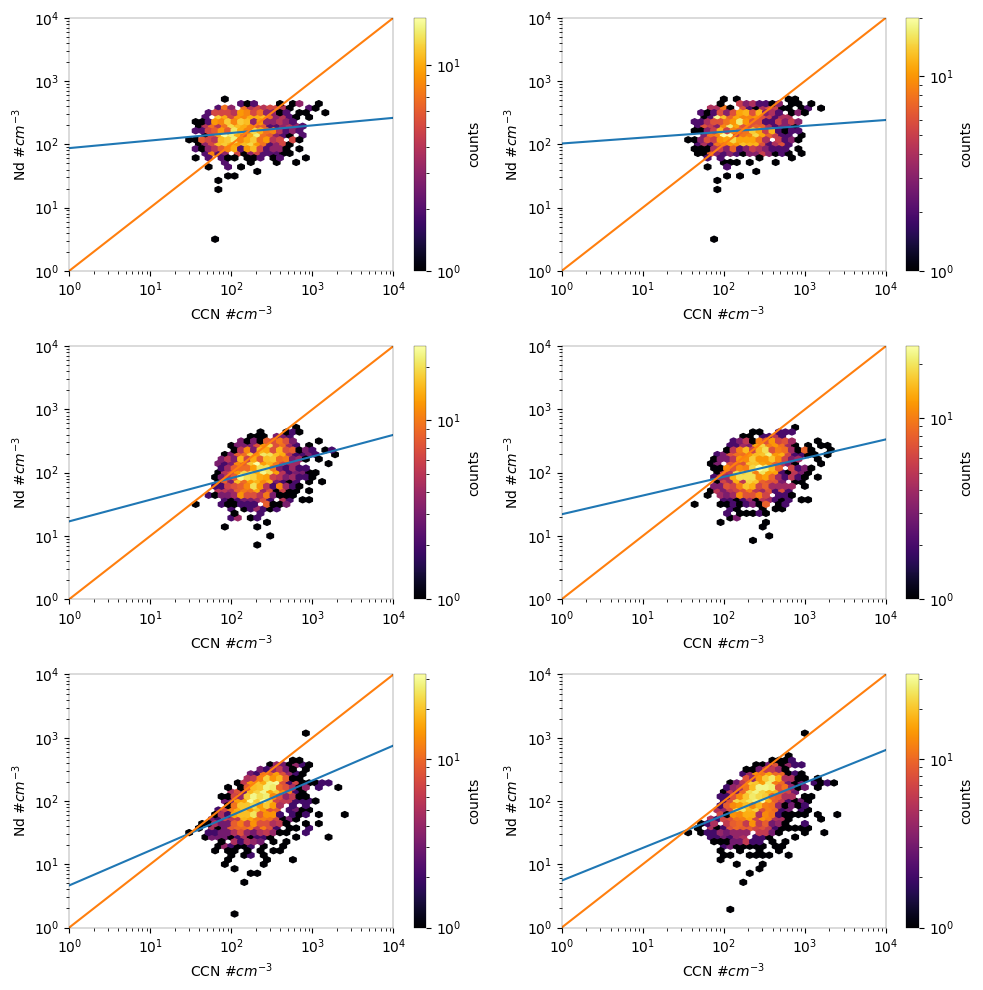

In [79]:
mydsfig = plt.figure(figsize = (10,10))

x = myds['ActivatedNumberUpdraft3'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,1)
NdtoCCNGraph(x,y)
SActUp3Lev1 = Susceptibility(x,y)
x = myds['ActivatedNumberUpdraft3CC'].isel(lev = -1).where(myds['DropletsCCUp3'].isel(lev =-1)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -1).where(myds['DropletsCCUp3'].isel(lev =-1)>0).dropna('time')

plt.subplot(3,2,2)
NdtoCCNGraph(x,y)
SActCCUp3Lev1 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft3'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -2).where(PeterNor['Droplets'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,3)
SActUp3Lev2 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft3CC'].isel(lev = -2).where(myds['DropletsCCUp3'].isel(lev =-2)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -2).where(myds['DropletsCCUp3'].isel(lev =-2)>0).dropna('time')

plt.subplot(3,2,4)
NdtoCCNGraph(x,y)
SActCCUp3Lev2 = Susceptibility(x,y)

x = myds['ActivatedNumberUpdraft3'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')
y = PeterNor['Droplets'].isel(lev = -3).where(PeterNor['Droplets'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,5)
SActUp3Lev3 = Susceptibility(x,y)
NdtoCCNGraph(x,y)

x = myds['ActivatedNumberUpdraft3CC'].isel(lev = -3).where(myds['DropletsCCUp3'].isel(lev =-3)>0).dropna('time')
y = myds['DropletsCCUp3'].isel(lev = -3).where(myds['DropletsCCUp3'].isel(lev =-3)>0).dropna('time')

plt.subplot(3,2,6)
NdtoCCNGraph(x,y)
SActCCUp3Lev3 = Susceptibility(x,y)
fig.suptitle('Updraft = 0.8')

plt.tight_layout()

In [80]:
ArrayList = [SBaseLev1, SActUp1Lev1, SActCCUp1Lev1, SActUp2Lev1, SActCCUp2Lev1,SActUp3Lev1, SActCCUp3Lev1]
SusceptibilityAcctivatedLev1_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityAcctivatedLev1_df = SusceptibilityAcctivatedLev1_df.T
SusceptibilityAcctivatedLev1_df.columns = ['Base','Activated Diameter & Updraft 1', 'Activated Diameter, CC & Updraft 1', 'Activated Diameter & Updraft 2' ,'Activated Diameter, CC & Updraft 2','Activated Diameter & Updraft 3', 'Activated Diameter, CC & Updraft 3']
SusceptibilityAcctivatedLev1_df.index = ['Level 1 Susceptibility', 'Standard Error']
SusceptibilityAcctivatedLev1_df

,Base,Activated Diameter & Updraft 1,"Activated Diameter, CC & Updraft 1",Activated Diameter & Updraft 2,"Activated Diameter, CC & Updraft 2",Activated Diameter & Updraft 3,"Activated Diameter, CC & Updraft 3"
Level 1 Susceptibility,0.083944,0.362183,0.360632,0.190506,0.156552,0.119546,0.092903
Standard Error,0.020524,0.022062,0.022113,0.023885,0.024190,0.024361,0.024433


In [81]:
ArrayList = [SBaseLev2, SActUp1Lev2, SActCCUp1Lev2, SActUp2Lev2, SActCCUp2Lev2,SActUp3Lev2, SActCCUp3Lev2]
SusceptibilityAcctivatedLev2_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityAcctivatedLev2_df = SusceptibilityAcctivatedLev2_df.T
SusceptibilityAcctivatedLev2_df.columns = ['Base','Activated Diameter & Updraft 1', 'Activated Diameter, CC & Updraft 1', 'Activated Diameter & Updraft 2' ,'Activated Diameter, CC & Updraft 2','Activated Diameter & Updraft 3', 'Activated Diameter, CC & Updraft 3']
SusceptibilityAcctivatedLev2_df.index = ['Level 2 Susceptibility', 'Standard Error']
SusceptibilityAcctivatedLev2_df

,Base,Activated Diameter & Updraft 1,"Activated Diameter, CC & Updraft 1",Activated Diameter & Updraft 2,"Activated Diameter, CC & Updraft 2",Activated Diameter & Updraft 3,"Activated Diameter, CC & Updraft 3"
Level 2 Susceptibility,0.271117,0.545168,0.562619,0.440265,0.386924,0.341783,0.295861
Standard Error,0.024056,0.022744,0.022850,0.027132,0.027879,0.028758,0.029167


In [82]:
ArrayList = [SBaseLev3, SActUp1Lev3, SActCCUp1Lev3, SActUp2Lev3, SActCCUp2Lev3,SActUp3Lev3, SActCCUp3Lev3]
SusceptibilityAcctivatedLev3_df = pd.DataFrame(np.vstack(ArrayList))
SusceptibilityAcctivatedLev3_df = SusceptibilityAcctivatedLev3_df.T
SusceptibilityAcctivatedLev3_df.columns = ['Base','Activated Diameter & Updraft 1', 'Activated Diameter, CC & Updraft 1', 'Activated Diameter & Updraft 2' ,'Activated Diameter, CC & Updraft 2','Activated Diameter & Updraft 3', 'Activated Diameter, CC & Updraft 3']
SusceptibilityAcctivatedLev3_df.index = ['Level 3 Susceptibility', 'Standard Error']
SusceptibilityAcctivatedLev3_df

,Base,Activated Diameter & Updraft 1,"Activated Diameter, CC & Updraft 1",Activated Diameter & Updraft 2,"Activated Diameter, CC & Updraft 2",Activated Diameter & Updraft 3,"Activated Diameter, CC & Updraft 3"
Level 3 Susceptibility,0.453035,0.630216,0.659279,0.619732,0.571007,0.552662,0.516003
Standard Error,0.021470,0.020174,0.020093,0.024599,0.025800,0.027007,0.027861


n70 = sum( numberconcentration_i * 1/2 (1-erf( ln(D70/Dg)/sqrt(ln(Dg)))

In [85]:
from scipy.special import erf
PeterNor['testN70']= sum( PeterNor[f'NCONC{i:02d}']/2*(1-erf(np.log(35/PeterNor[f'NMR{i:02d}'])/np.sqrt(np.log(PeterNor[f'SIGMA{i:02d}'])))) for i in [1,2,4,5,6,7,8,9,10,12,14])

In [86]:
PeterNor['testN70'] = PeterNor['testN70'].compute()
plt.scatter(PeterNor['testN70'].isel(lev = -1), PeterNor['Totaln70'].isel(lev = -1))
plt.plot([1,7000], [1,7000], linestyle = '-')

KeyboardInterrupt: 

In [ ]:
NdtoCCNGraph(PeterNor['testN70'].isel(lev = -1).where(PeterNor['Droplets'].isel(lev = -1) >0).dropna('time'), PeterNor['Droplets'].isel(lev = -1).dropna('time'))

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.datasets import make_blobs

def compute_Wk(data, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=2).fit(data)
    cluster_centers = kmeans.cluster_centers_
    labels = kmeans.labels_
    Wk = 0
    for i in range(n_clusters):
        cluster_data = data[labels == i]
        Wk += np.sum(pairwise_distances(cluster_data, [cluster_centers[i]])**2)
    return Wk

def gap_statistic(data, refs=5, max_k=10):
    shape = data.shape
    gaps = []
    s_k = []
    wk_refs = np.zeros((max_k, refs))

    for k in range(1, max_k + 1):
        wk = compute_Wk(data, k)
        for i in range(refs):
            random_ref = np.random.uniform(np.min(data, axis=0), np.max(data, axis=0), size=shape)
            wk_refs[k - 1, i] = compute_Wk(random_ref, k)
        wk_log = np.log(wk)
        wk_ref_log = np.log(wk_refs[k - 1])
        gap = np.mean(wk_ref_log) - wk_log
        sk = np.std(wk_ref_log) * np.sqrt(1 + 1.0 / refs)
        gaps.append(gap)
        s_k.append(sk)

    return np.array(gaps), np.array(s_k)

# Example use
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)

gaps, sks = gap_statistic(PeterNor['TotaldNdlogD'].isel(lev = -1), refs=10, max_k=10)

# Plotting
import matplotlib.pyplot as plt
plt.plot(range(1, 11), gaps, marker='o')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic vs. Number of Clusters')
plt.show()


In [ ]:
Gaps = []
for i in range(len(gaps) - 1):
    diff = gaps[i] - gaps[i + 1] + sks[i + 1]
    Gaps.append(diff)

# Find the first k where the condition is met
optimal_k = next((i + 1 for i, g in enumerate(Gaps) if g >= 0), len(gaps))
print("Optimal number of clusters (k):", optimal_k)

In [ ]:
gaps[0]